# الخطوة 2 — إنشاء Wald-Style Training Patches

هذه الـNotebook تُجهّز بيانات التدريب من:

- `Aligned_Data/MS_aligned.tif`
- `Aligned_Data/PAN_aligned.tif`

لدينا:

- MS أصلية: `6 × 1536 × 1804`
- PAN أصلية: `1 × 6144 × 7216`
- فرق الدقة: `×4`

لا توجد صورة High-Resolution Multispectral حقيقية. لذلك سنبني تجربة **Reduced Resolution**:

```text
MS الأصلية                  → Target MS
MS بعد التصغير ×4           → Input LR-MS
PAN بعد التصغير إلى حجم MS  → Input PAN
```

شكل كل عينة:

```text
LR-MS:     6 × 64 × 64
PAN:       1 × 256 × 256
Target-MS: 6 × 256 × 256
```

> هذه النسخة تستخدم **4×4 area averaging** كـLow-pass degradation مبدئي، لأن معلومات MTF الخاصة بالمستشعر غير متاحة. لاحقًا يمكن مقارنتها بـGaussian/MTF degradation كتجربة بحثية.


## 1) تثبيت المكتبات وربط Google Drive

In [1]:
!pip install -q rasterio numpy pandas matplotlib

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2) تحديد المسارات وإعداد فولدر البيانات

In [2]:
from pathlib import Path
import shutil

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Super_Resolution_28-07-2026"
)

MS_PATH = PROJECT_DIR / "Aligned_Data" / "MS_aligned.tif"
PAN_PATH = PROJECT_DIR / "Aligned_Data" / "PAN_aligned.tif"

WALD_DIR = PROJECT_DIR / "Wald_Data"
RR_DIR = WALD_DIR / "Reduced_Resolution"
PATCHES_DIR = WALD_DIR / "Patches"
PREVIEW_DIR = WALD_DIR / "Previews"

MANIFEST_PATH = WALD_DIR / "patch_manifest.csv"
STATS_PATH = WALD_DIR / "normalization_stats.json"

for folder in [WALD_DIR, RR_DIR, PATCHES_DIR, PREVIEW_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("MS موجودة :", MS_PATH.exists(), MS_PATH)
print("PAN موجودة:", PAN_PATH.exists(), PAN_PATH)
print("Output:", WALD_DIR)

if not MS_PATH.exists():
    raise FileNotFoundError("MS_aligned.tif غير موجود.")
if not PAN_PATH.exists():
    raise FileNotFoundError("PAN_aligned.tif غير موجود.")


MS موجودة : True /content/drive/MyDrive/Super_Resolution_28-07-2026/Aligned_Data/MS_aligned.tif
PAN موجودة: True /content/drive/MyDrive/Super_Resolution_28-07-2026/Aligned_Data/PAN_aligned.tif
Output: /content/drive/MyDrive/Super_Resolution_28-07-2026/Wald_Data


## 3) قراءة الصور والتأكد من العلاقة ×4

In [3]:
import rasterio
import numpy as np

SCALE = 4

with rasterio.open(MS_PATH) as ms_src, rasterio.open(PAN_PATH) as pan_src:
    print("MS shape :", (ms_src.count, ms_src.height, ms_src.width))
    print("PAN shape:", (pan_src.count, pan_src.height, pan_src.width))
    print("Same CRS :", ms_src.crs == pan_src.crs)
    print("Same bounds:", ms_src.bounds == pan_src.bounds)

    assert ms_src.count == 6
    assert pan_src.count == 1
    assert pan_src.height == ms_src.height * SCALE
    assert pan_src.width == ms_src.width * SCALE
    assert ms_src.crs == pan_src.crs

    ms = ms_src.read()
    pan = pan_src.read(1)

    ms_profile = ms_src.profile.copy()
    pan_profile = pan_src.profile.copy()
    ms_transform = ms_src.transform
    crs = ms_src.crs
    ms_bounds = ms_src.bounds

print("\nتم تحميل الصور.")
print("MS dtype :", ms.dtype)
print("PAN dtype:", pan.dtype)


MS shape : (6, 1536, 1804)
PAN shape: (1, 6144, 7216)
Same CRS : True
Same bounds: True

تم تحميل الصور.
MS dtype : uint16
PAN dtype: uint16


## 4) إنشاء الصور منخفضة الدقة

سنستخدم المتوسط داخل كل بلوك `4×4`.

### PAN

```text
6144 × 7216
      ↓ ÷4
1536 × 1804
```

### MS

```text
1536 × 1804
      ↓ ÷4
384 × 451
```

طريقة المتوسط تمنع أخذ Pixel واحدة وإهمال بقية المنطقة.


In [4]:
def area_downsample_2d(array, factor=4):
    """تصغير مصفوفة ثنائية الأبعاد بمتوسط بلوكات factor × factor."""
    h, w = array.shape

    if h % factor != 0 or w % factor != 0:
        raise ValueError(
            f"الأبعاد {h}×{w} غير قابلة للقسمة على {factor}."
        )

    reduced = array.reshape(
        h // factor,
        factor,
        w // factor,
        factor
    ).mean(axis=(1, 3), dtype=np.float32)

    return reduced


def area_downsample_multiband(array, factor=4):
    """تصغير صورة بالشكل Bands × Height × Width."""
    bands, h, w = array.shape

    if h % factor != 0 or w % factor != 0:
        raise ValueError(
            f"الأبعاد {h}×{w} غير قابلة للقسمة على {factor}."
        )

    reduced = array.reshape(
        bands,
        h // factor,
        factor,
        w // factor,
        factor
    ).mean(axis=(2, 4), dtype=np.float32)

    return reduced


# PAN منخفضة إلى مستوى MS الأصلي
pan_rr_float = area_downsample_2d(pan, SCALE)

# MS منخفضة 4 مرات لتصبح مدخل LR-MS
lr_ms_float = area_downsample_multiband(ms, SCALE)

# الاحتفاظ بدقة القيم ثم التحويل إلى UInt16 لتقليل الحجم
pan_rr = np.clip(
    np.rint(pan_rr_float),
    0,
    np.iinfo(np.uint16).max
).astype(np.uint16)

lr_ms = np.clip(
    np.rint(lr_ms_float),
    0,
    np.iinfo(np.uint16).max
).astype(np.uint16)

print("Target MS:", ms.shape)
print("RR PAN   :", pan_rr.shape)
print("LR MS    :", lr_ms.shape)

assert pan_rr.shape == (ms.shape[1], ms.shape[2])
assert lr_ms.shape == (
    ms.shape[0],
    ms.shape[1] // SCALE,
    ms.shape[2] // SCALE
)


Target MS: (6, 1536, 1804)
RR PAN   : (1536, 1804)
LR MS    : (6, 384, 451)


## 5) حفظ صور Reduced Resolution للفحص

سيتم حفظ:

```text
Wald_Data/Reduced_Resolution/
├── PAN_RR_at_MS_scale.tif
└── MS_LR_x4.tif
```


In [5]:
from affine import Affine

PAN_RR_PATH = RR_DIR / "PAN_RR_at_MS_scale.tif"
MS_LR_PATH = RR_DIR / "MS_LR_x4.tif"

def clean_profile(profile):
    profile = profile.copy()
    for key in [
        "blockxsize",
        "blockysize",
        "photometric",
        "interleave",
    ]:
        profile.pop(key, None)
    return profile


# PAN_RR على شبكة MS الأصلية
rr_pan_profile = clean_profile(ms_profile)
rr_pan_profile.update(
    driver="GTiff",
    width=ms.shape[2],
    height=ms.shape[1],
    count=1,
    dtype="uint16",
    transform=ms_transform,
    crs=crs,
    nodata=0,
    compress="deflate",
    predictor=2,
    tiled=True,
    blockxsize=256,
    blockysize=256,
    interleave="band",
    BIGTIFF="IF_SAFER",
)

with rasterio.open(PAN_RR_PATH, "w", **rr_pan_profile) as dst:
    dst.write(pan_rr, 1)


# LR-MS: Pixel size أكبر 4 مرات
lr_transform = ms_transform * Affine.scale(SCALE, SCALE)

lr_ms_profile = clean_profile(ms_profile)
lr_ms_profile.update(
    driver="GTiff",
    width=lr_ms.shape[2],
    height=lr_ms.shape[1],
    count=lr_ms.shape[0],
    dtype="uint16",
    transform=lr_transform,
    crs=crs,
    compress="deflate",
    predictor=2,
    tiled=True,
    blockxsize=256,
    blockysize=256,
    interleave="band",
    BIGTIFF="IF_SAFER",
)

with rasterio.open(MS_LR_PATH, "w", **lr_ms_profile) as dst:
    dst.write(lr_ms)

print("تم الحفظ:")
print(PAN_RR_PATH)
print(MS_LR_PATH)


تم الحفظ:
/content/drive/MyDrive/Super_Resolution_28-07-2026/Wald_Data/Reduced_Resolution/PAN_RR_at_MS_scale.tif
/content/drive/MyDrive/Super_Resolution_28-07-2026/Wald_Data/Reduced_Resolution/MS_LR_x4.tif


## 6) تحديد التقسيم المكاني قبل التقطيع

لن نوزّع الـPatches عشوائيًا.

سنستخدم شرائط رأسية منفصلة وبينها مسافة Gap:

```text
0                                                    1804
|--------- Train ---------| Gap |-- Val --| Gap |-- Test --| unused
0                        896    960       1344   1408       1792
```

- Train: من `x=0` إلى `x=896`
- Validation: من `x=960` إلى `x=1344`
- Test: من `x=1408` إلى `x=1792`
- Gap: 64 Pixel بين المناطق
- آخر 12 Pixel لن تُستخدم

الـGap يقلل تسرب تفاصيل متجاورة بين Train وValidation/Test.


In [6]:
TARGET_PATCH = 256
LR_PATCH = TARGET_PATCH // SCALE

TRAIN_STRIDE = 64
EVAL_STRIDE = 128

SPLITS = {
    "train": {
        "x_start": 0,
        "x_end": 896,
        "stride": TRAIN_STRIDE,
    },
    "val": {
        "x_start": 960,
        "x_end": 1344,
        "stride": EVAL_STRIDE,
    },
    "test": {
        "x_start": 1408,
        "x_end": 1792,
        "stride": EVAL_STRIDE,
    },
}

image_h = ms.shape[1]
image_w = ms.shape[2]

print("Image H × W:", image_h, "×", image_w)
print("Target patch:", TARGET_PATCH, "×", TARGET_PATCH)
print("LR-MS patch :", LR_PATCH, "×", LR_PATCH)

for split_name, cfg in SPLITS.items():
    width = cfg["x_end"] - cfg["x_start"]

    assert cfg["x_start"] % SCALE == 0
    assert cfg["x_end"] % SCALE == 0
    assert width >= TARGET_PATCH

    print(
        split_name,
        "x-range:",
        cfg["x_start"],
        "→",
        cfg["x_end"],
        "width:",
        width,
    )


Image H × W: 1536 × 1804
Target patch: 256 × 256
LR-MS patch : 64 × 64
train x-range: 0 → 896 width: 896
val x-range: 960 → 1344 width: 384
test x-range: 1408 → 1792 width: 384


## 7) معاينة التقسيم المكاني

الخطوط الرأسية تحدد بدايات ونهايات Train وValidation وTest.


In [7]:
import matplotlib.pyplot as plt
from rasterio.enums import Resampling

def stretch_band(band):
    band = band.astype(np.float32)
    valid = band[np.isfinite(band) & (band > 0)]

    if valid.size == 0:
        return np.zeros_like(band, dtype=np.float32)

    low, high = np.percentile(valid, [2, 98])

    if high <= low:
        return np.zeros_like(band, dtype=np.float32)

    return np.clip((band - low) / (high - low), 0, 1)


rgb_full = np.stack(
    [
        stretch_band(ms[2]),
        stretch_band(ms[1]),
        stretch_band(ms[0]),
    ],
    axis=-1
)

plt.figure(figsize=(16, 12))
plt.imshow(rgb_full)

for split_name, cfg in SPLITS.items():
    plt.axvline(cfg["x_start"], linewidth=2)
    plt.axvline(cfg["x_end"], linewidth=2)

    center = (cfg["x_start"] + cfg["x_end"]) / 2
    plt.text(
        center,
        60,
        split_name.upper(),
        ha="center",
        va="center",
        fontsize=12,
        bbox={"facecolor": "white", "alpha": 0.75},
    )

plt.title("Spatial Train / Validation / Test Split")
plt.axis("off")
plt.show()


Output hidden; open in https://colab.research.google.com to view.

## 8) حساب إحصاءات التطبيع من Train فقط

سنحفظ Percentiles وMean وStandard Deviation لكل Band.

مهم: لا نستخدم Validation أو Test لحساب التطبيع، حتى لا يحدث Data Leakage.


In [8]:
import json

train_x0 = SPLITS["train"]["x_start"]
train_x1 = SPLITS["train"]["x_end"]

train_target = ms[:, :, train_x0:train_x1]
train_pan = pan_rr[:, train_x0:train_x1]

stats = {
    "scale": SCALE,
    "target_patch": TARGET_PATCH,
    "lr_patch": LR_PATCH,
    "ms_bands": [],
    "pan": {},
}

for band_index in range(train_target.shape[0]):
    band = train_target[band_index].astype(np.float32)
    valid = band[np.isfinite(band) & (band > 0)]

    band_stats = {
        "band": band_index + 1,
        "min": float(valid.min()),
        "max": float(valid.max()),
        "mean": float(valid.mean()),
        "std": float(valid.std()),
        "p01": float(np.percentile(valid, 1)),
        "p99": float(np.percentile(valid, 99)),
    }

    stats["ms_bands"].append(band_stats)


valid_pan = train_pan.astype(np.float32)
valid_pan = valid_pan[np.isfinite(valid_pan) & (valid_pan > 0)]

stats["pan"] = {
    "min": float(valid_pan.min()),
    "max": float(valid_pan.max()),
    "mean": float(valid_pan.mean()),
    "std": float(valid_pan.std()),
    "p01": float(np.percentile(valid_pan, 1)),
    "p99": float(np.percentile(valid_pan, 99)),
}

with open(STATS_PATH, "w", encoding="utf-8") as f:
    json.dump(stats, f, indent=2, ensure_ascii=False)

print("Saved:", STATS_PATH)
print("\nMS band percentiles:")
for item in stats["ms_bands"]:
    print(
        f"Band {item['band']}:",
        f"P01={item['p01']:.2f}",
        f"P99={item['p99']:.2f}"
    )

print(
    "\nPAN:",
    f"P01={stats['pan']['p01']:.2f}",
    f"P99={stats['pan']['p99']:.2f}"
)


Saved: /content/drive/MyDrive/Super_Resolution_28-07-2026/Wald_Data/normalization_stats.json

MS band percentiles:
Band 1: P01=788.00 P99=4775.00
Band 2: P01=803.00 P99=3941.00
Band 3: P01=838.00 P99=3017.00
Band 4: P01=812.00 P99=5385.00
Band 5: P01=854.00 P99=5224.00
Band 6: P01=967.00 P99=2526.00

PAN: P01=767.00 P99=4418.00


## 9) إنشاء الـPatches

كل ملف `.npz` سيحتوي على:

- `lr_ms`: الشكل `(6, 64, 64)`
- `pan`: الشكل `(1, 256, 256)`
- `target_ms`: الشكل `(6, 256, 256)`
- `x`, `y`: موقع الـPatch داخل صورة Target MS

سيتم حذف أي Patches تحتوي على NoData بنسبة كبيرة.


In [9]:
import pandas as pd
from rasterio.windows import Window, bounds as window_bounds

MAX_NODATA_FRACTION = 0.20


def patch_positions(start, end, patch_size, stride):
    """إنشاء مواقع تغطي النطاق، وإضافة آخر موقع عند الحاجة."""
    last_start = end - patch_size

    if last_start < start:
        return []

    positions = list(range(start, last_start + 1, stride))

    if positions[-1] != last_start:
        positions.append(last_start)

    return positions


def nodata_fraction(array):
    """نسبة القيم صفر عبر جميع القنوات والبكسلات."""
    return float(np.mean(array == 0))


# حذف Patches قديمة حتى لا تختلط بالتشغيل الجديد
for split_name in SPLITS:
    split_dir = PATCHES_DIR / split_name

    if split_dir.exists():
        shutil.rmtree(split_dir)

    split_dir.mkdir(parents=True, exist_ok=True)


manifest_rows = []

for split_name, cfg in SPLITS.items():

    split_dir = PATCHES_DIR / split_name

    x_positions = patch_positions(
        cfg["x_start"],
        cfg["x_end"],
        TARGET_PATCH,
        cfg["stride"],
    )

    y_positions = patch_positions(
        0,
        image_h,
        TARGET_PATCH,
        cfg["stride"],
    )

    saved_count = 0
    skipped_count = 0

    for y in y_positions:
        for x in x_positions:

            if x % SCALE != 0 or y % SCALE != 0:
                raise ValueError(
                    f"Patch start must be divisible by {SCALE}: x={x}, y={y}"
                )

            target_patch = ms[
                :,
                y:y + TARGET_PATCH,
                x:x + TARGET_PATCH
            ]

            pan_patch = pan_rr[
                y:y + TARGET_PATCH,
                x:x + TARGET_PATCH
            ][None, :, :]

            lr_y = y // SCALE
            lr_x = x // SCALE

            lr_ms_patch = lr_ms[
                :,
                lr_y:lr_y + LR_PATCH,
                lr_x:lr_x + LR_PATCH
            ]

            # التحقق من الأشكال
            assert target_patch.shape == (
                6,
                TARGET_PATCH,
                TARGET_PATCH
            )

            assert pan_patch.shape == (
                1,
                TARGET_PATCH,
                TARGET_PATCH
            )

            assert lr_ms_patch.shape == (
                6,
                LR_PATCH,
                LR_PATCH
            )

            target_nodata = nodata_fraction(target_patch)
            pan_nodata = nodata_fraction(pan_patch)
            lr_nodata = nodata_fraction(lr_ms_patch)

            if max(target_nodata, pan_nodata, lr_nodata) > MAX_NODATA_FRACTION:
                skipped_count += 1
                continue

            file_name = (
                f"{split_name}_"
                f"y{y:04d}_x{x:04d}.npz"
            )

            file_path = split_dir / file_name

            np.savez_compressed(
                file_path,
                lr_ms=lr_ms_patch,
                pan=pan_patch,
                target_ms=target_patch,
                x=np.int32(x),
                y=np.int32(y),
                scale=np.int32(SCALE),
            )

            geo_bounds = window_bounds(
                Window(x, y, TARGET_PATCH, TARGET_PATCH),
                ms_transform,
            )

            manifest_rows.append({
                "split": split_name,
                "file": str(file_path.relative_to(WALD_DIR)),
                "x": x,
                "y": y,
                "lr_height": LR_PATCH,
                "lr_width": LR_PATCH,
                "pan_height": TARGET_PATCH,
                "pan_width": TARGET_PATCH,
                "target_height": TARGET_PATCH,
                "target_width": TARGET_PATCH,
                "target_nodata_fraction": target_nodata,
                "pan_nodata_fraction": pan_nodata,
                "lr_nodata_fraction": lr_nodata,
                "left": geo_bounds[0],
                "bottom": geo_bounds[1],
                "right": geo_bounds[2],
                "top": geo_bounds[3],
            })

            saved_count += 1

    print(
        f"{split_name}:",
        f"saved={saved_count},",
        f"skipped={skipped_count},",
        f"x_positions={len(x_positions)},",
        f"y_positions={len(y_positions)}"
    )


manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(
    MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("\nManifest saved:", MANIFEST_PATH)
print("\nPatch counts:")
display(manifest.groupby("split").size().rename("count"))


train: saved=231, skipped=0, x_positions=11, y_positions=21
val: saved=22, skipped=0, x_positions=2, y_positions=11
test: saved=22, skipped=0, x_positions=2, y_positions=11

Manifest saved: /content/drive/MyDrive/Super_Resolution_28-07-2026/Wald_Data/patch_manifest.csv

Patch counts:


,count
split,
test,22
train,231
val,22


## 10) فحص ملفات عشوائية من كل Split

In [10]:
import random

for split_name in ["train", "val", "test"]:
    split_files = sorted(
        (PATCHES_DIR / split_name).glob("*.npz")
    )

    if not split_files:
        print(split_name, ": لا توجد ملفات.")
        continue

    sample_path = random.choice(split_files)

    with np.load(sample_path) as sample:
        print("\n", split_name.upper())
        print("File     :", sample_path.name)
        print("LR-MS    :", sample["lr_ms"].shape, sample["lr_ms"].dtype)
        print("PAN      :", sample["pan"].shape, sample["pan"].dtype)
        print("Target-MS:", sample["target_ms"].shape, sample["target_ms"].dtype)
        print("Location :", int(sample["x"]), int(sample["y"]))



 TRAIN
File     : train_y0640_x0128.npz
LR-MS    : (6, 64, 64) uint16
PAN      : (1, 256, 256) uint16
Target-MS: (6, 256, 256) uint16
Location : 128 640

 VAL
File     : val_y1152_x0960.npz
LR-MS    : (6, 64, 64) uint16
PAN      : (1, 256, 256) uint16
Target-MS: (6, 256, 256) uint16
Location : 960 1152

 TEST
File     : test_y0128_x1536.npz
LR-MS    : (6, 64, 64) uint16
PAN      : (1, 256, 256) uint16
Target-MS: (6, 256, 256) uint16
Location : 1536 128


## 11) عرض عينة من Train

سنقارن:

1. LR-MS بعد تكبيرها للعرض فقط.
2. PAN عند مستوى Target.
3. Target MS الأصلية.

الهدف ليس قياس الجودة الآن؛ الهدف التأكد أن الثلاث صور تمثل نفس المكان.


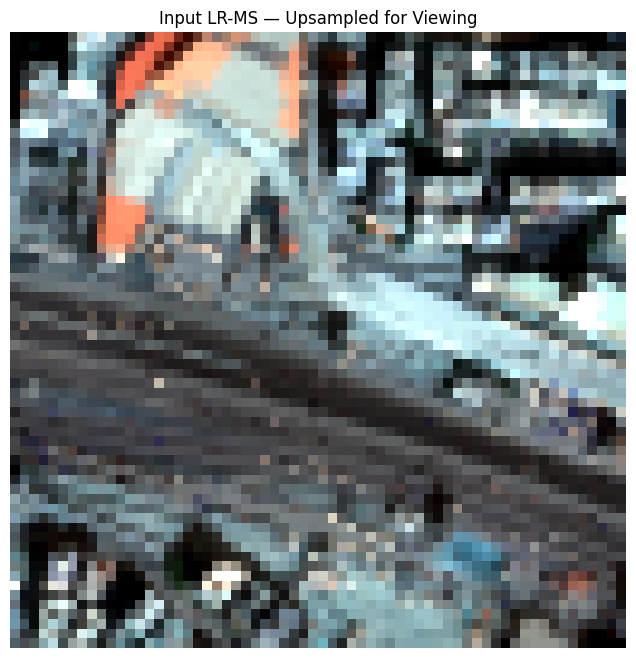

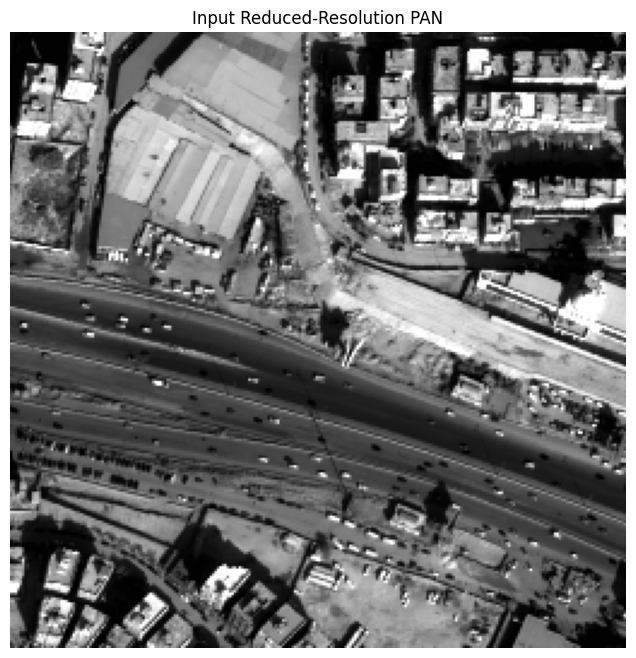

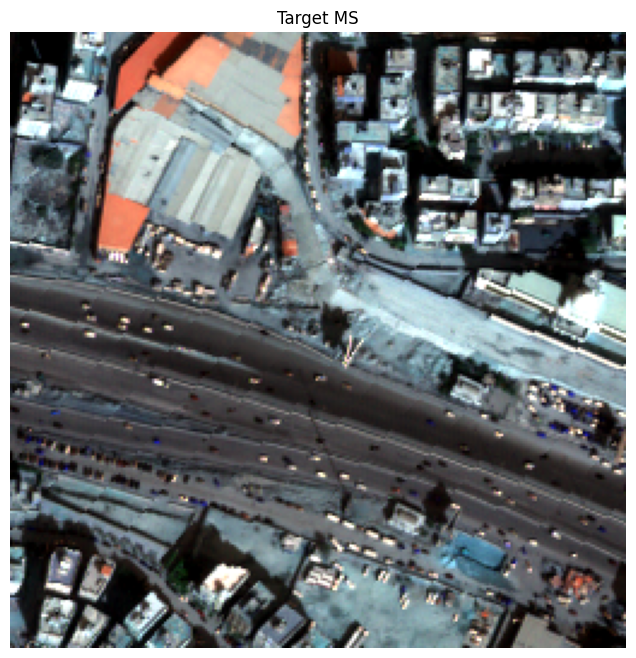

Sample: /content/drive/MyDrive/Super_Resolution_28-07-2026/Wald_Data/Patches/train/train_y0640_x0320.npz


In [11]:
from rasterio.enums import Resampling

train_files = sorted(
    (PATCHES_DIR / "train").glob("*.npz")
)

if not train_files:
    raise RuntimeError("لا توجد Train patches.")

sample_path = train_files[len(train_files) // 2]

with np.load(sample_path) as sample:
    sample_lr = sample["lr_ms"]
    sample_pan = sample["pan"][0]
    sample_target = sample["target_ms"]


def rgb_from_321(array):
    return np.stack(
        [
            stretch_band(array[2]),
            stretch_band(array[1]),
            stretch_band(array[0]),
        ],
        axis=-1
    )


# تكبير LR-MS للعرض فقط
lr_rgb = rgb_from_321(sample_lr)

lr_rgb_up = np.repeat(
    np.repeat(lr_rgb, SCALE, axis=0),
    SCALE,
    axis=1
)

target_rgb = rgb_from_321(sample_target)
pan_show = stretch_band(sample_pan)

plt.figure(figsize=(8, 8))
plt.imshow(lr_rgb_up, interpolation="nearest")
plt.title("Input LR-MS — Upsampled for Viewing")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(pan_show, cmap="gray")
plt.title("Input Reduced-Resolution PAN")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(target_rgb)
plt.title("Target MS")
plt.axis("off")
plt.show()

print("Sample:", sample_path)


## 12) فحص التطابق العددي بين المواقع

إذا نجحت هذه الخلية، فمقاسات الـPatches والعلاقة ×4 صحيحة.


In [ ]:
assert not manifest.empty

for split_name in ["train", "val", "test"]:
    split_manifest = manifest[manifest["split"] == split_name]

    if split_manifest.empty:
        raise RuntimeError(f"No patches in split: {split_name}")

    for _, row in split_manifest.head(5).iterrows():
        patch_path = WALD_DIR / row["file"]

        with np.load(patch_path) as sample:
            assert sample["lr_ms"].shape == (6, 64, 64)
            assert sample["pan"].shape == (1, 256, 256)
            assert sample["target_ms"].shape == (6, 256, 256)

            assert int(sample["x"]) % SCALE == 0
            assert int(sample["y"]) % SCALE == 0

print("كل اختبارات الأشكال والمواقع نجحت.")


# ما الذي ترسله بعد التشغيل؟

أرسل:

1. نتيجة عدد الـPatches في Train / Val / Test.
2. ناتج فحص Shape لعينة من كل Split.
3. الصور الثلاث:
   - `Input LR-MS`
   - `Input Reduced-Resolution PAN`
   - `Target MS`
4. أي Error يظهر.

بعد التأكد، ستكون الخطوة التالية:

> بناء PyTorch Dataset Loader ثم تشغيل Baseline بسيط قبل تعديل HAT.
